## gwEccEvolve_NoSpinq4 : SVD surrogate model for eccentricity evolution in non-spinning binaries
Presented by Islam et al. (https://arxiv.org/abs/2604.17868)

In [1]:
import sys
# install gwModels in editable mode from the parent directory
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### Load the model

In [2]:
model = gwModels.dynamics.gwEccEvolve_NoSpinq4('../data/gwEccEvolve_NoSpinq4.npy')
model.info()

gwEccEvolve_NoSpinq4 — SVD surrogate for eccentricity evolution
  Time domain : [-6300, -1] M
  q range     : [1.000, 4.000]
  e0 range    : [0.003, 0.443]
  SVD basis   : 2 components


### Single evaluation

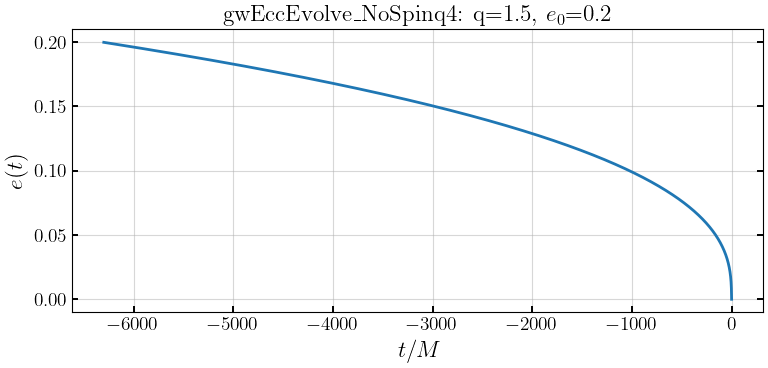

In [3]:
t = np.linspace(-6300, -1, 63000)
q, e0 = 1.5, 0.2

ecc = model(t, q=q, e0=e0)

plt.figure(figsize=(8, 4))
plt.plot(t, ecc, lw=2)
plt.xlabel('$t/M$')
plt.ylabel('$e(t)$')
plt.title(f'gwEccEvolve_NoSpinq4: q={q}, $e_0$={e0}')
plt.tight_layout()
plt.show()

### Evaluation with uncertainty

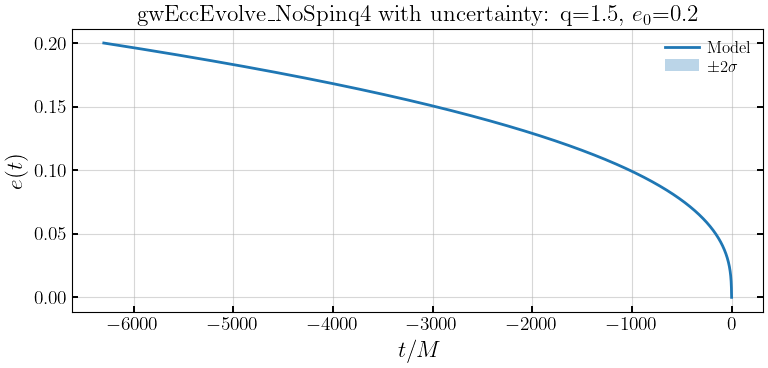

In [4]:
ecc, ecc_std = model(t, q=q, e0=e0, return_std=True)

plt.figure(figsize=(8, 4))
plt.plot(t, ecc, lw=2, label='Model')
plt.fill_between(t, ecc - 2*ecc_std, ecc + 2*ecc_std, alpha=0.3, label='$\\pm 2\\sigma$')
plt.xlabel('$t/M$')
plt.ylabel('$e(t)$')
plt.title(f'gwEccEvolve_NoSpinq4 with uncertainty: q={q}, $e_0$={e0}')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Parameter-space sweep

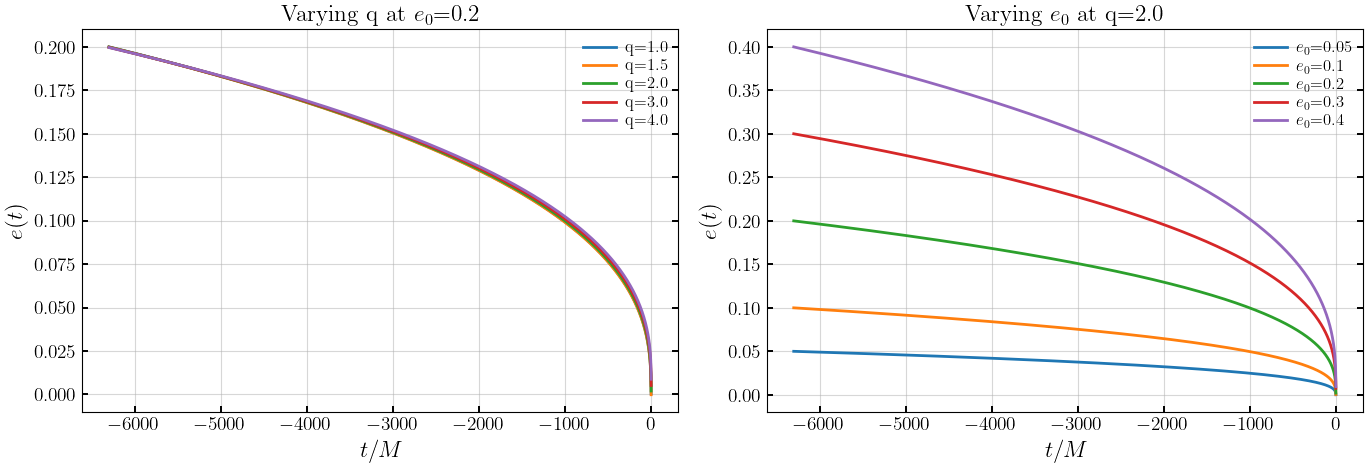

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vary q at fixed e0
e0_fixed = 0.2
for q_test in [1.0, 1.5, 2.0, 3.0, 4.0]:
    ecc_pred = model(t, q=q_test, e0=e0_fixed)
    axes[0].plot(t, ecc_pred, lw=2, label=f'q={q_test}')
axes[0].set_xlabel('$t/M$')
axes[0].set_ylabel('$e(t)$')
axes[0].set_title(f'Varying q at $e_0$={e0_fixed}')
axes[0].legend(frameon=False)

# Vary e0 at fixed q
q_fixed = 2.0
for e0_test in [0.05, 0.1, 0.2, 0.3, 0.4]:
    ecc_pred = model(t, q=q_fixed, e0=e0_test)
    axes[1].plot(t, ecc_pred, lw=2, label=f'$e_0$={e0_test}')
axes[1].set_xlabel('$t/M$')
axes[1].set_ylabel('$e(t)$')
axes[1].set_title(f'Varying $e_0$ at q={q_fixed}')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()